In [26]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



df = pd.read_csv('/Users/leonardo/Desktop/dsml_lab/Lab5/train_dataset.csv')

y = df['target']
X = df.drop(columns=['target'])




In [27]:
cols = len(X.columns)
for row in X.index:
    if (X.iloc[row,:].isna().sum())/cols >= 0.5:
        print(row)

# nothing to drop 

In [28]:
X.head()

,cont_0,cont_1,cont_2,cont_3,cont_4,cont_5,cont_6,cont_7,cont_8,cont_9,...,ord_18,ord_19,cat_0,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7
0,-0.029933,19.494106,-4.330267,NaN,-6.403516,-12.474620,NaN,-0.180768,440.930299,NaN,...,NaN,ord_7_val_5,cat_0_val_9,cat_1_val_2,cat_2_val_1,cat_3_val_10,cat_4_val_0,cat_5_val_0,cat_6_val_0,cat_7_val_1
1,0.004747,1.930336,2.370512,0.014357,-2.381447,2.545120,-652.050389,NaN,NaN,NaN,...,ord_7_val_2,ord_7_val_4,cat_0_val_2,cat_1_val_1,NaN,cat_3_val_9,NaN,cat_5_val_0,cat_6_val_0,cat_7_val_5
2,NaN,18.865632,1.826231,-0.033690,-7.177250,8.423474,-3322.816093,6.550298,-137.358945,NaN,...,ord_7_val_2,ord_7_val_4,cat_0_val_6,cat_1_val_3,NaN,NaN,cat_4_val_0,cat_5_val_0,cat_6_val_0,cat_7_val_1
3,-0.017541,NaN,9.851084,0.035294,1.077285,4.897107,-647.925452,-2.024097,NaN,11.097455,...,NaN,ord_7_val_4,cat_0_val_2,NaN,cat_2_val_2,cat_3_val_18,NaN,NaN,cat_6_val_0,cat_7_val_5
4,0.005074,-32.895531,-12.880423,0.025106,NaN,1.029729,-3938.124133,NaN,172.214384,9.974146,...,ord_7_val_2,ord_7_val_1,cat_0_val_3,cat_1_val_0,cat_2_val_0,cat_3_val_13,NaN,cat_5_val_0,cat_6_val_0,cat_7_val_3


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

#print(X_train.head())
#print(X_test.head())


In [30]:
# Separate continous, ordinal and categorical attributes both for test and train

X_train_cont= X_train.loc[:,"cont_0":"cont_29"]
X_train_ord = X_train.loc[:, "ord_0":"ord_19"]
X_train_cat = X_train.loc[:,"cat_0":"cat_7"]

X_test_cont = X_test.loc[:,"cont_0":"cont_29"]
X_test_ord = X_test.loc[:, "ord_0":"ord_19"]
X_test_cat = X_test.loc[:,"cat_0":"cat_7"]


In [31]:

zscore_s = StandardScaler()
X_train_cont_norm = pd.DataFrame(zscore_s.fit_transform(X_train_cont), columns=X_train_cont.columns)
X_test_cont_norm = pd.DataFrame(zscore_s.transform(X_test_cont), columns=X_test_cont.columns)


for col in X_train_cont_norm.columns:
    print(col, str(np.mean(X_train_cont_norm[col])), ' ' , str(np.std(X_train_cont_norm[col])))

# fillna with the mean (0)

X_train_cont_norm.fillna(0, inplace=True)
X_test_cont_norm.fillna(0, inplace=True)



cont_0 -2.2328507757824378e-17   0.9999999999999999
cont_1 -1.150676495158057e-17   1.0
cont_2 4.915209848921556e-18   0.9999999999999999
cont_3 1.518253708889103e-17   1.0
cont_4 8.325907435843468e-18   1.0
cont_5 2.4555665460329698e-17   1.0
cont_6 -3.905153810168179e-17   1.0
cont_7 4.142531219034454e-17   0.9999999999999999
cont_8 -4.3932980364392015e-17   1.0
cont_9 -8.456473332345074e-18   0.9999999999999999
cont_10 1.1786719420958255e-17   0.9999999999999999
cont_11 2.0035936840553032e-17   0.9999999999999999
cont_12 5.549580394034512e-17   1.0
cont_13 -2.584514707577309e-17   1.0
cont_14 -2.9393659780478495e-18   1.0
cont_15 -6.964154508990061e-18   1.0
cont_16 -2.2843839701540822e-17   1.0
cont_17 -1.947759692324836e-18   1.0
cont_18 -7.335402126987641e-17   1.0
cont_19 2.002092802930685e-17   1.0
cont_20 2.5474505143081363e-17   1.0
cont_21 -4.93295428880936e-18   1.0
cont_22 5.838721644825336e-17   1.0
cont_23 9.954367270385265e-19   0.9999999999999999
cont_24 -1.50046490521

In [32]:
X_train_cont_norm.head()

,cont_0,cont_1,cont_2,cont_3,cont_4,cont_5,cont_6,cont_7,cont_8,cont_9,...,cont_20,cont_21,cont_22,cont_23,cont_24,cont_25,cont_26,cont_27,cont_28,cont_29
0,0.837902,0.000000,-0.496731,-0.044483,-1.735044,1.702756,-0.966988,1.353399,-0.301429,0.976158,...,-1.247317,-2.211194,0.201452,1.259152,0.000000,-0.725377,0.356719,-0.978322,0.000000,0.000000
1,-0.244560,-0.135503,0.000000,-0.141183,-0.350069,0.422898,0.000000,0.043426,-0.340424,-0.261500,...,0.000000,-1.012078,-0.793316,-0.273002,-0.933684,1.184148,-0.655242,0.771918,0.146090,0.504136
2,-1.964329,-1.374252,-1.777665,0.000000,-2.109041,-1.286856,-1.418924,0.080185,1.767198,1.981112,...,-1.070020,0.000000,-0.935035,0.000000,1.277429,-1.810045,0.000000,0.000000,0.000000,1.641277
3,1.639627,-1.328609,0.000000,-1.241018,0.867481,-0.428017,0.250532,0.000000,-2.072083,-0.783889,...,-1.159800,-0.150278,-0.011283,0.698128,1.055323,0.089182,1.280182,-1.478773,-0.909681,-1.327178
4,0.000000,1.806050,-1.851068,-2.326377,0.000000,-1.578154,-0.860455,2.027799,0.346274,-0.498699,...,-0.259726,-0.912863,1.315115,-0.500954,0.000000,-0.324356,0.900590,-0.470151,-2.088655,1.700580


In [33]:

oe = OrdinalEncoder()
X_train_ord_oe = pd.DataFrame(oe.fit_transform(X_train_ord), columns=X_train_ord.columns)
X_test_ord_oe = pd.DataFrame(oe.transform(X_test_ord), columns=X_test_ord.columns)

#for i in X_ord.columns:
#    print(X_ord[i].unique())
X_train_ord_oe.fillna(-1, inplace=True)
X_test_ord_oe.fillna(-1, inplace=True)

X_train_ord_oe.head()


,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,ord_6,ord_7,ord_8,ord_9,ord_10,ord_11,ord_12,ord_13,ord_14,ord_15,ord_16,ord_17,ord_18,ord_19
0,4.0,1.0,-1.0,-1.0,2.0,4.0,2.0,3.0,0.0,0.0,-1.0,2.0,2.0,3.0,-1.0,-1.0,2.0,0.0,3.0,0.0
1,-1.0,1.0,2.0,3.0,1.0,6.0,2.0,-1.0,0.0,0.0,3.0,1.0,2.0,2.0,2.0,1.0,1.0,-1.0,2.0,3.0
2,4.0,0.0,0.0,7.0,0.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0,-1.0,0.0,0.0,0.0,2.0,-1.0,0.0,5.0
3,5.0,0.0,0.0,-1.0,2.0,8.0,2.0,0.0,-1.0,1.0,0.0,3.0,2.0,4.0,3.0,-1.0,2.0,-1.0,-1.0,0.0
4,4.0,1.0,3.0,4.0,1.0,3.0,0.0,0.0,-1.0,-1.0,3.0,-1.0,2.0,4.0,0.0,3.0,2.0,0.0,3.0,0.0


In [34]:
# Drop categorical columns with only one category plus NaN

for i in X_train_cat.columns:
    num = len((X_train_cat[i].unique()))
    if num <= 2:
        X_train_cat.drop(columns={i}, inplace=True)
        X_test_cat.drop(columns={i}, inplace=True)

X_train_cat.fillna('missing', inplace=True)
X_test_cat.fillna('missing', inplace=True)

In [35]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, dtype=int, handle_unknown='ignore')
X_train_cat_ohe = pd.DataFrame(ohe.fit_transform(X_train_cat))
X_test_cat_ohe = pd.DataFrame(ohe.transform(X_test_cat))

In [36]:
X_train_cat_ohe.head()

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
0,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0


In [37]:
X_train_new = np.hstack((X_train_cont_norm, X_train_ord_oe, X_train_cat_ohe))
X_test_new = np.hstack((X_test_cont_norm, X_test_ord_oe, X_test_cat_ohe))

In [38]:
pd.DataFrame(X_train_new).head()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,100,101
0,0.837902,0.000000,-0.496731,-0.044483,-1.735044,1.702756,-0.966988,1.353399,-0.301429,0.976158,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.244560,-0.135503,0.000000,-0.141183,-0.350069,0.422898,0.000000,0.043426,-0.340424,-0.261500,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.964329,-1.374252,-1.777665,0.000000,-2.109041,-1.286856,-1.418924,0.080185,1.767198,1.981112,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.639627,-1.328609,0.000000,-1.241018,0.867481,-0.428017,0.250532,0.000000,-2.072083,-0.783889,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000000,1.806050,-1.851068,-2.326377,0.000000,-1.578154,-0.860455,2.027799,0.346274,-0.498699,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
pd.DataFrame(X_test_new).isna().sum()

0      0
1      0
2      0
3      0
4      0
      ..
97     0
98     0
99     0
100    0
101    0
Length: 102, dtype: int64

In [40]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

param_grid_lasso = {'alpha': np.logspace(-4, 1, 20), 'fit_intercept': [True, False]}

reg = Lasso()
gridsearch = GridSearchCV(reg, param_grid_lasso, scoring='r2', cv=5)
gridsearch.fit(X_train_new, y_train)

/Users/leonardo/Desktop/dsml_lab/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.982e+01, tolerance: 3.534e-01
  model = cd_fast.enet_coordinate_descent(


,estimator,Lasso()
,param_grid,"{'alpha': array([1.0000...00000000e+01]), 'fit_intercept': [True, False]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0....8378916846883)


In [41]:
best_configurated_model = gridsearch.best_estimator_

In [42]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

y_test_pred = best_configurated_model.predict(X_test_new)
# Compute R2, MAE and MSE:
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print('r2 metric: ', r2)
print('mae metric: ', mae)
print('mse metrice: ', mse)

r2 metric:  0.28886576275958264
mae metric:  0.6526665687854918
mse metrice:  0.69715716246547


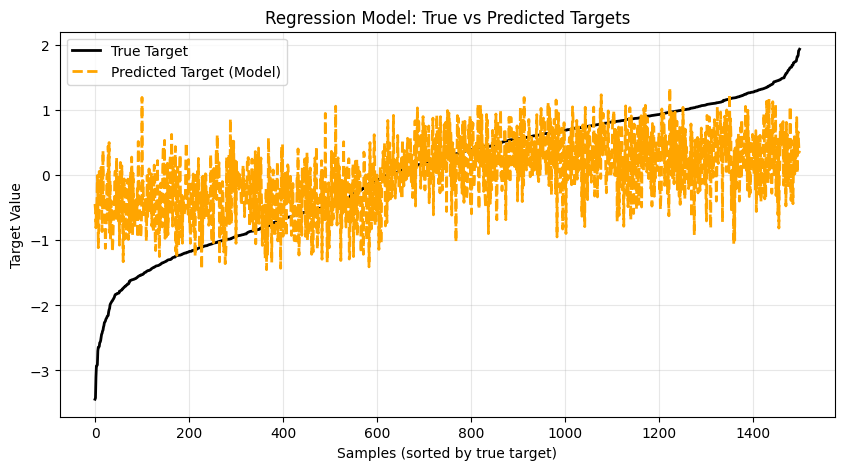

In [43]:
# Ordina i valori per il target reale, così il confronto è chiaro
sorted_idx = np.argsort(y_test)
y_true_sorted = np.array(y_test)[sorted_idx]
y_pred_sorted = np.array(y_test_pred)[sorted_idx]

plt.figure(figsize=(10,5))
plt.plot(y_true_sorted, label='True Target', color='black', linewidth=2)
plt.plot(y_pred_sorted, label='Predicted Target (Model)', color='orange', linestyle='--', linewidth=2)
plt.title("Regression Model: True vs Predicted Targets")
plt.xlabel("Samples (sorted by true target)")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
model = make_pipeline(
    PolynomialFeatures(include_bias=False),
    Lasso(max_iter=10000)
)
param_grid = {
    'polynomialfeatures__degree': [1, 2],
    'lasso__alpha': np.logspace(-3, 1, 10)
}

grid = GridSearchCV(model, param_grid, scoring='r2', cv=5, n_jobs=-1)
grid.fit(X_train_new, y_train)

print("Best params:", grid.best_params_)
print("Best cross-val R²:", grid.best_score_)


best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_new)

print(f"Test R²: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")



Best params: {'lasso__alpha': np.float64(0.007742636826811269), 'polynomialfeatures__degree': 2}
Best cross-val R²: 0.7295451929800147
Test R²: 0.726
MAE: 0.382
MSE: 0.269


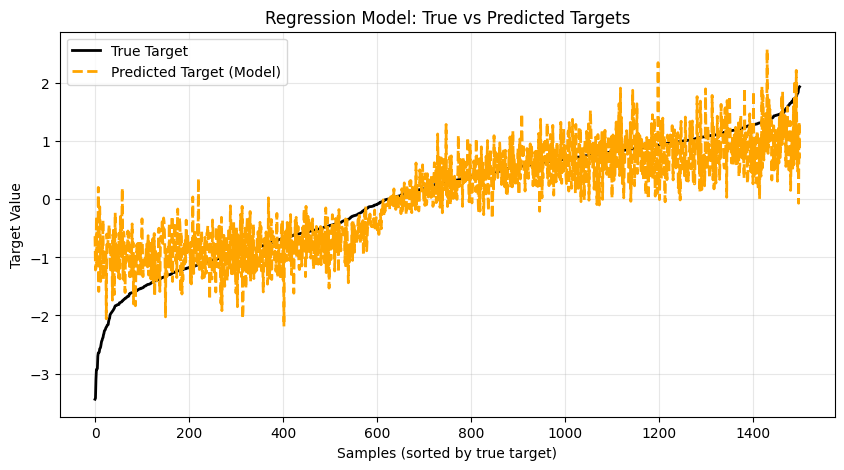

In [45]:
# Ordina i valori per il target reale, così il confronto è chiaro
sorted_idx = np.argsort(y_test)
y_true_sorted = np.array(y_test)[sorted_idx]
y_pred_sorted = np.array(y_pred)[sorted_idx]

plt.figure(figsize=(10,5))
plt.plot(y_true_sorted, label='True Target', color='black', linewidth=2)
plt.plot(y_pred_sorted, label='Predicted Target (Model)', color='orange', linestyle='--', linewidth=2)
plt.title("Regression Model: True vs Predicted Targets")
plt.xlabel("Samples (sorted by true target)")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
